# Marconi Alpha Sweep — swesmith dataset

Sweep `alpha` values for the Marconi eviction strategy and plot token-level hit rate.

**Config:** dataset=swesmith, max_requests=5000, ordering=random, page_size=32, capacity=160GB, mamba_state_token_equiv=1000

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import KV_BYTES_PER_TOKEN_DEFAULT
from experiments.runner import (
    capacity_from_spec,
    effective_page_size,
    prepare_requests,
    run_simulation,
    strategy_from_name,
)

# --- Fixed parameters ---
DATASET = "swesmith"
MAX_REQUESTS = 5000
ORDERING = "random"
PAGE_SIZE = 32
CAPACITY_SPEC = "160"
MAMBA_STATE_TOKEN_EQUIV = 1000
SEED = 0

page_size = effective_page_size(DATASET, PAGE_SIZE)
cap = capacity_from_spec(CAPACITY_SPEC, KV_BYTES_PER_TOKEN_DEFAULT)

print("Preparing requests...")
requests = prepare_requests(
    DATASET, ORDERING, seed=SEED,
    tokenize_workers=90, max_requests=MAX_REQUESTS,
)
print(f"Got {len(requests)} requests, capacity={cap} tokens")

Preparing requests...


/data/howarli/dev/LLM-prefix-caching-simulator/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Got 5000 requests, capacity=374491 tokens


In [2]:
import multiprocessing as mp
import numpy as np
from src.strategies.marconi import MarconiStrategy

# --- Worker runs in forked process, inherits `requests` via COW ---
_SHARED_REQUESTS = None
_SHARED_PAGE_SIZE = None
_SHARED_CAP = None
_SHARED_MAMBA = None

def _init_pool(reqs, ps, c, m):
    global _SHARED_REQUESTS, _SHARED_PAGE_SIZE, _SHARED_CAP, _SHARED_MAMBA
    _SHARED_REQUESTS = reqs
    _SHARED_PAGE_SIZE = ps
    _SHARED_CAP = c
    _SHARED_MAMBA = m

def _run_one_alpha(alpha):
    strategy = MarconiStrategy(alpha=alpha)
    metrics = run_simulation(
        _SHARED_REQUESTS, _SHARED_PAGE_SIZE, strategy,
        _SHARED_CAP, _SHARED_MAMBA,
    )
    return (alpha, metrics.token_level_hit_rate)

MAX_WORKERS = 10

def sweep_parallel(alphas):
    """Run all alphas in parallel using fork-based pool."""
    ctx = mp.get_context("fork")
    results = {}
    with ctx.Pool(
        processes=min(MAX_WORKERS, len(alphas)),
        initializer=_init_pool,
        initargs=(requests, page_size, cap, MAMBA_STATE_TOKEN_EQUIV),
    ) as pool:
        for alpha, hr in pool.imap_unordered(_run_one_alpha, alphas):
            results[alpha] = hr
            print(f"  alpha={alpha:.1f}  token_hr={hr:.4f}")
    return results

# Coarse sweep: 0.0 to 5.0 in steps of 0.5
alphas_coarse = [round(x, 1) for x in np.arange(0.0, 5.5, 0.5)]
print(f"Coarse sweep: {len(alphas_coarse)} alphas, {MAX_WORKERS} workers")
results_coarse = sweep_parallel(alphas_coarse)

best_coarse = max(results_coarse, key=results_coarse.get)
print(f"\nBest coarse alpha: {best_coarse:.1f} (hr={results_coarse[best_coarse]:.4f})")

Coarse sweep: 11 alphas, 10 workers
  alpha=4.0  token_hr=0.2965
  alpha=4.5  token_hr=0.2935
  alpha=3.0  token_hr=0.3052
  alpha=3.5  token_hr=0.3006
  alpha=2.5  token_hr=0.3125
  alpha=2.0  token_hr=0.3163
  alpha=1.5  token_hr=0.3202
  alpha=0.0  token_hr=0.2439
  alpha=1.0  token_hr=0.2721
  alpha=0.5  token_hr=0.2512
  alpha=5.0  token_hr=0.2909

Best coarse alpha: 1.5 (hr=0.3202)


In [3]:
# Fine sweep: +/- 0.5 around best coarse, in steps of 0.1
lo = max(0.0, best_coarse - 0.5)
hi = best_coarse + 0.6
alphas_fine = [round(x, 1) for x in np.arange(lo, hi, 0.1)]
# Skip alphas already computed
alphas_new = [a for a in alphas_fine if a not in results_coarse]

print(f"Fine sweep: {len(alphas_new)} new alphas")
results_fine = sweep_parallel(alphas_new) if alphas_new else {}

# Merge all results
all_results = {**results_coarse, **results_fine}
best_alpha = max(all_results, key=all_results.get)
print(f"\nBest alpha: {best_alpha:.1f} (token_hr={all_results[best_alpha]:.4f})")

Fine sweep: 8 new alphas
  alpha=1.8  token_hr=0.3188
  alpha=1.9  token_hr=0.3173
  alpha=1.4  token_hr=0.3172
  alpha=1.7  token_hr=0.3195
  alpha=1.6  token_hr=0.3224
  alpha=1.3  token_hr=0.3146
  alpha=1.2  token_hr=0.3086
  alpha=1.1  token_hr=0.2977

Best alpha: 1.6 (token_hr=0.3224)


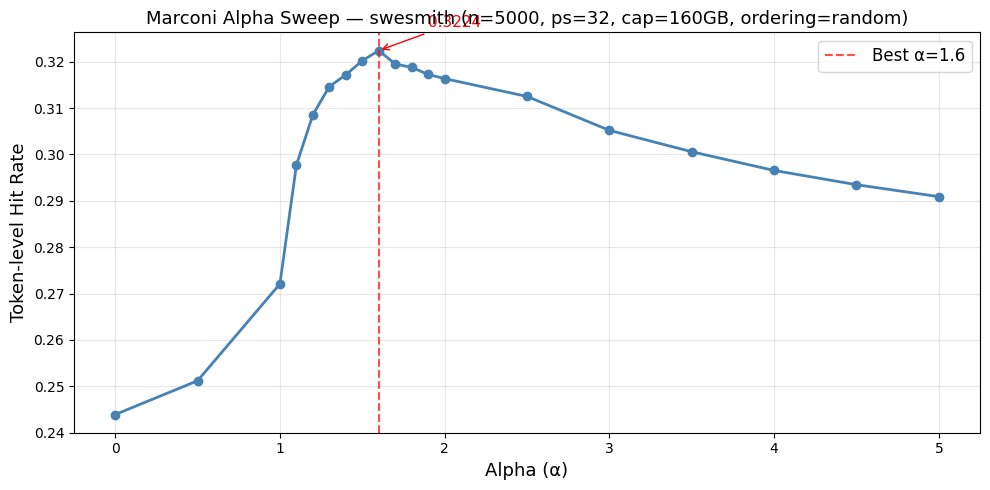


Optimal alpha = 1.6, token hit rate = 0.3224


In [4]:
import matplotlib.pyplot as plt

sorted_alphas = sorted(all_results.keys())
hrs = [all_results[a] for a in sorted_alphas]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_alphas, hrs, "o-", color="steelblue", markersize=6, linewidth=2)
ax.axvline(best_alpha, color="red", linestyle="--", alpha=0.7, label=f"Best α={best_alpha:.1f}")
ax.set_xlabel("Alpha (α)", fontsize=13)
ax.set_ylabel("Token-level Hit Rate", fontsize=13)
ax.set_title(
    f"Marconi Alpha Sweep — swesmith (n={MAX_REQUESTS}, ps={PAGE_SIZE}, "
    f"cap={CAPACITY_SPEC}GB, ordering={ORDERING})",
    fontsize=13,
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Annotate best point
ax.annotate(
    f"{all_results[best_alpha]:.4f}",
    xy=(best_alpha, all_results[best_alpha]),
    xytext=(best_alpha + 0.3, all_results[best_alpha] + 0.005),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11, color="red",
)

plt.tight_layout()
plt.savefig("marconi_alpha_sweep.png", dpi=150)
plt.show()
print(f"\nOptimal alpha = {best_alpha:.1f}, token hit rate = {all_results[best_alpha]:.4f}")